In [3]:
# Стилизация отчета в стиле Notion
from IPython.display import HTML, display

style = """
<style>
    /* Центрирование основного контейнера ноутбука */
    #notebook-container, .container, .jp-Notebook {
        max-width: 1000px !important;
        margin: 0 auto !important;
        background-color: E8E8E8 !important;
        box-shadow: none !important;
    }
    
   /* Выравнивание вывода (output) по левому краю внутри контейнера */
    .output_subarea, .jp-OutputArea-output {
        text-align: left !important;
        padding: 0 !important;
    }

    /* 1. Центрируем контейнер с результатами выполнения */
    .jp-OutputArea-child, .output_area {
        max-width: 800px; /* Ширина "Notion-блока" */
        margin: 0 auto !important;
        text-align: left; 
    }

    /* Выравнивание markdown по ширине */
    .jp-MarkdownOutput p,
    .jp-MarkdownOutput li,
    .text_cell_render p,
    .text_cell_render li {
        text-align: justify !important;
        text-justify: inter-word !important;
    }

    .jp-MarkdownOutput h1,
    .jp-MarkdownOutput h2,
    .jp-MarkdownOutput h3,
    .jp-MarkdownOutput h4,
    .text_cell_render h1,
    .text_cell_render h2,
    .text_cell_render h3,
    .text_cell_render h4 {
        text-align: left !important;
    }
        
    /* 2. Делаем таблицы Pandas аккуратными (в стиле Notion) */
    table.dataframe {
        border: none !important;
        margin: 0 auto !important;
        font-family: sans-serif !important;
        border-collapse: collapse !important;
    }

    table.dataframe th { 
        padding: 8px !important;
        border-bottom: 2px solid #8C8C8C !important;
        text-align: left !important;
    }
    
    table.dataframe td {     
        border-bottom: 1px solid #8C8C8C !important;
    }

    /* 3. Центрируем графики (matplotlib, plotly) */
    .output_png img,
    .jp-OutputArea-output img {
        width: 100% !important;
        height: auto !important;
    }
</style>
"""
display(HTML(style))

<h1><strong> EDA ANALYSIS (РАЗВЕДОЧНЫЙ АНАЛИЗ) </strong></h1>

<b><i>Explorarity Data Analysis</i></b> - анализ основных свойств данных, нахождение в них общих закономерностей, распределений и аномалий, построение начальных моделей, зачастую с использованием инструментов визуализации.<br>
<b>Источник:</b> [Sample-Superstore-Dataset from Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

In [65]:
# Импорт нужных библиотек
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as GridSpec
import seaborn as sns
import os
import clickhouse_connect
import statistics as stats

# Стиль для графиков
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
## Подключение к базе данных ClickHouse и загрузка данных в DataFrame
# Данные для подключения к ClickHouse
ch_host = 'localhost'
ch_port = '8123'
ch_user = os.getenv('CLICKHOUSE_USER')
ch_password = os.getenv('CLICKHOUSE_PASSWORD')
ch_database = 'dwh'

# Создание соединение с ClickHouse
ch_connect = clickhouse_connect.get_client(
    host=ch_host,
    port=ch_port,
    username=ch_user,
    password=ch_password,
    database=ch_database
)

<h3><strong> 1. ОБЗОР ДАТАСЕТА </strong></h3>

В данном этапе анализа будет загружен датасет, который был извлечен с clickhouse (dwh схема). Будет определены типы данных столбцов, также основные параметры таблицы (кол-во столбцов и строк, количество уникальных значений основных столбцов).

In [6]:
# Загрузка и чтение данных с clickhouse
df = ch_connect.query_df('SELECT * FROM dwh.sales_fact')
print("\033[1m" + 'ТАБЛИЦА ПО ПРОДАЖАМ ЗАГРУЖЕНА УСПЕШНО!' + "\033[1m" + '\n')
# Вывод первых и последних 5 строк таблицы
display(df)

ТАБЛИЦА ПО ПРОДАЖАМ ЗАГРУЖЕНА УСПЕШНО!



,order_id,row_id,order_date,customer_name,segment,city,state,region,product_name,category,sub_category,ship_mode,ship_status,profit,quantity,discount,sales,sales_forecast
0,CA-2018-103800,7981,2018-01-03,Darren Powers,Consumer,Houston,Texas,Central,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Office Supplies,Paper,Standard Class,Shipped Early,6,2,0.2,16,25
1,CA-2018-112326,740,2018-01-04,Phillina Ober,Home Office,Naperville,Illinois,Central,Avery 508,Office Supplies,Labels,Standard Class,Shipped Early,4,3,0.2,12,18
2,CA-2018-112326,741,2018-01-04,Phillina Ober,Home Office,Naperville,Illinois,Central,SAFCO Boltless Steel Shelving,Office Supplies,Storage,Standard Class,Shipped Early,65,3,0.2,273,408
3,CA-2018-112326,742,2018-01-04,Phillina Ober,Home Office,Naperville,Illinois,Central,GBC Standard Plastic Binding Systems Combs,Office Supplies,Binders,Standard Class,Shipped Early,5,2,0.8,4,5
4,CA-2018-141817,1760,2018-01-05,Mick Brown,Consumer,Philadelphia,Pennsylvania,East,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Office Supplies,Art,Standard Class,Shipped Late,5,3,0.2,20,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2021-143259,909,2021-12-30,Patrick O'Donnell,Consumer,New York City,New York,East,Wilson Jones Legal Size Ring Binders,Office Supplies,Binders,Standard Class,Shipped Early,20,3,0.2,53,79
9990,CA-2021-143259,908,2021-12-30,Patrick O'Donnell,Consumer,New York City,New York,East,Gear Head AU3700S Headset,Technology,Phones,Standard Class,Shipped Early,3,7,0.0,91,136
9991,CA-2021-156720,5092,2021-12-30,Jill Matthias,Consumer,Loveland,Colorado,West,Bagged Rubber Bands,Office Supplies,Fasteners,Standard Class,Shipped Early,1,3,0.2,3,5
9992,CA-2021-115427,1297,2021-12-30,Erica Bern,Corporate,Fairfield,California,West,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",Office Supplies,Binders,Standard Class,Shipped Early,5,2,0.2,14,21


In [7]:
# Таблица с типа данных
df_types = df.dtypes.reset_index().rename(columns={0: 'Тип данных', 'index': 'Название колонки'})

# Функция для информации о количестве уникальных значений в важных колонках и других параметрах
def get_nuniques(df):
    # Создаем список словарей с уникальными параметрами и их значениями
    stats = [
        {"Параметр": "Количество строк", "Значение": str(len(df))},
        {"Параметр": "Количество столбцов", "Значение": str(len(df.columns))},
        {"Параметр": "Количество заказов", "Значение": str(len(df.order_id.unique()))},
        {"Параметр": "Охваченные годы", "Значение": f"{df.order_date.dt.year.min()} - {df.order_date.dt.year.max()}"},
        {"Параметр": "Количество клиентов", "Значение": str(len(df.customer_name.unique()))},
        {"Параметр": "Количество сегментов", "Значение": str(len(df.segment.unique()))},
        {"Параметр": "Количество городов", "Значение": str(len(df.city.unique()))},
        {"Параметр": "Количество продуктов", "Значение": str(len(df.product_name.unique()))},
        {"Параметр": "Количество субкатегорий", "Значение": str(len(df.sub_category.unique()))},
    ]

    info_df = pd.DataFrame(stats)
    return info_df

# Таблица с информацией о количестве уникальных значений в важных колонках и других параметрах
info_nuniques = get_nuniques(df)

In [8]:
# Стилизация для вывода двух таблиц рядом
html_output = f"""
<div style="display: flex; justify-content: space-around; align-items: flex-start; max-width: 1000px; margin: 0 auto;">
    
    <div style="flex: 1; padding: 10px;">
        <h4 style="text-align: center;">ТИПЫ ДАННЫХ КОЛОНОК:</h4>
        {df_types.to_html(index=False, classes='notion-style')}
    </div>
    
    <div style="flex: 1; padding: 10px;">
        <h4 style="text-align: center;">ОСНОВНЫЕ ПАРАМЕТРЫ:</h4>
        {info_nuniques.to_html(index=False, classes='notion-style')}
    </div>

</div>

<style>
    .notion-style {{
        width: 100% !important;
        border-collapse: collapse !important;
        font-family: sans-serif !important;
        font-size: 13px !important;
    }}
    .notion-style td, .notion-style th {{
        padding: 8px !important;
        border-bottom: 1px 8C8C8C #eee !important;
        text-align: left !important;
    }}

</style>
"""

display(HTML(html_output))
print()

Название колонки,Тип данных
order_id,string
row_id,uint16
order_date,datetime64[ns]
customer_name,string
segment,string
city,string
state,string
region,string
product_name,string
category,string


<h3><strong> 2. КАЧЕСТВО ДАННЫХ </strong></h3>
Нужно проверить таблицу на пустые значения в колонках и на наличие дубликатов в строках.

In [9]:
# Проверка на пропуски в данных
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].reset_index().rename(columns={'index': 'Колонка', 0: 'Количество пропусков'})
if missing_values.empty:
    print("\033[1m" + '- ПРОПУСКОВ В ДАННЫХ НЕ ОБНАРУЖЕНО!' + "\033[1m")
else:
    display(missing_values)

- ПРОПУСКОВ В ДАННЫХ НЕ ОБНАРУЖЕНО!


In [10]:
# Проверка на дубликаты в данных
duplicate_count = df.duplicated().sum()
if duplicate_count == 0:
    print("\033[1m" + '- ДУБЛИКАТОВ В ДАННЫХ НЕ ОБНАРУЖЕНО!')
else:
    print(duplicate_count)
print()

- ДУБЛИКАТОВ В ДАННЫХ НЕ ОБНАРУЖЕНО!



<h3><strong> 3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА </strong></h3>
Данный этап нужен для выявления базовой описательной статистики: <br>
- Минимум и максимум, среднее, медиана числовых столбцов <br>
- Cтандартное отклонение, дисперсия, квартили <br>
- Выбросы (outliers)

In [11]:
# Вывод базовой описательной статистики по числовым колонкам
def describe_df (df):
    cols = ['profit', 'quantity', 'discount', 'sales', 'sales_forecast']
 
    for i in cols:
        stats = [
            {'Статистика': 'Минимальные значения', **{col: df[col].min() for col in cols}},
            {'Статистика': '25-ый квартиль', **{col: df[col].quantile(0.25) for col in cols}},
            {'Статистика': 'Медиана', **{col: df[col].median() for col in cols}},
            {'Статистика': '75-ый квартиль', **{col: df[col].quantile(0.75) for col in cols}},
            {'Статистика': 'Максимальные значения', **{col: df[col].max() for col in cols}},
            {'Статистика': 'Среднее значения', **{col: df[col].mean() for col in cols}},
            {'Статистика': 'Стандартное отклонение', **{col: df[col].std() for col in cols}},
            {'Статистика': 'Дисперсия', **{col: df[col].var() for col in cols}},
            
        ]
        info = pd.DataFrame(stats)

    pd.options.display.float_format = '{:,.2f}'.format
    return info

# Таблица с описательной статистикой
display(describe_df(df))
print()

,Статистика,profit,quantity,discount,sales,sales_forecast
0,Минимальные значения,0.00,1.00,0.00,0.00,1.00
1,25-ый квартиль,5.00,2.00,0.00,17.00,26.00
2,Медиана,14.00,3.00,0.20,54.50,82.00
3,75-ый квартиль,43.00,5.00,0.20,210.00,314.00
4,Максимальные значения,"8,400.00",14.00,0.80,"22,638.00","33,903.00"
5,Среднее значения,59.90,3.79,0.16,229.87,344.24
6,Стандартное отклонение,228.27,2.23,0.21,623.25,933.36
7,Дисперсия,"52,108.59",4.95,0.04,"388,439.25","871,169.33"


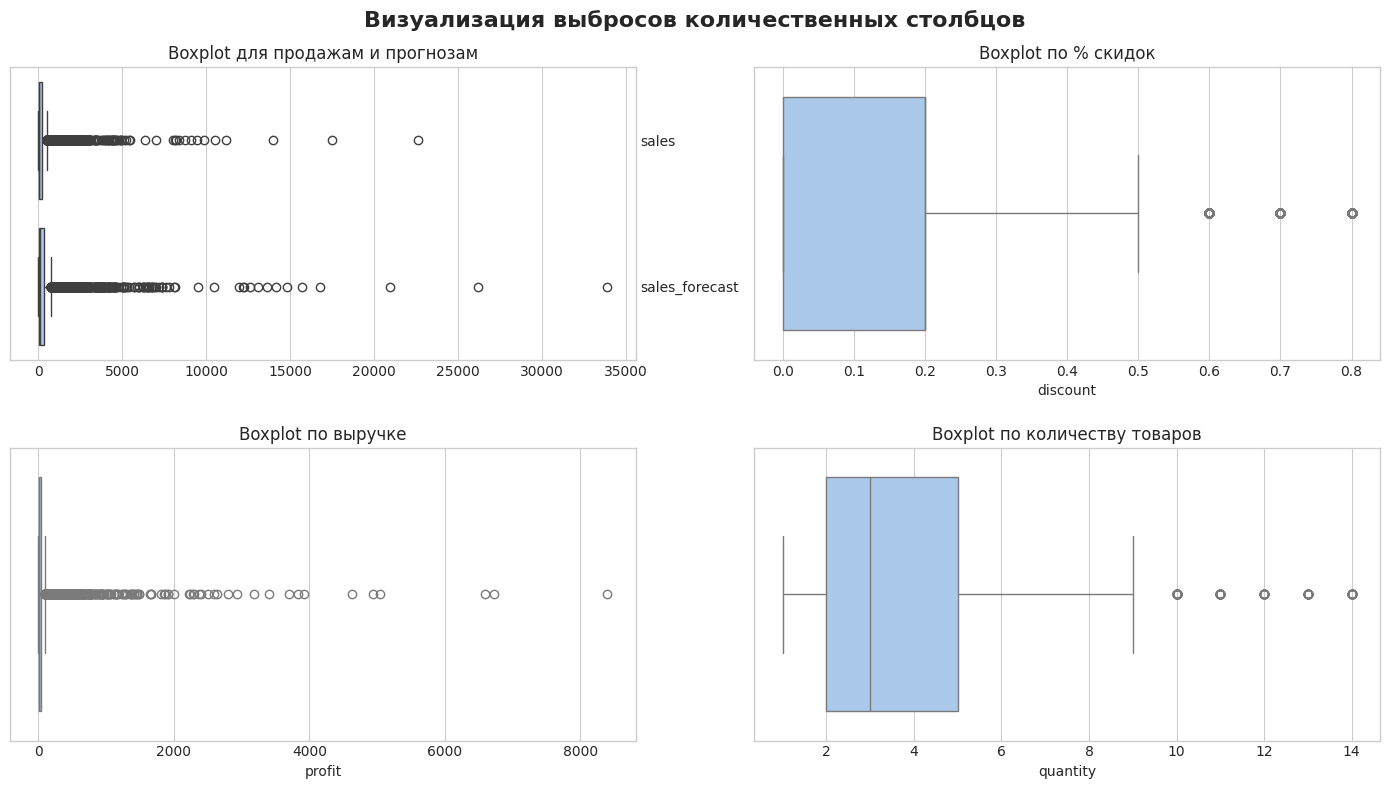

In [12]:
# Визуализация выбросов
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Визуализация выбросов количественных столбцов', fontsize=16, fontweight='bold')

sns.boxplot(data=df[['sales', 'sales_forecast']], orient='h', ax=axes[0,0], color='#a1c9f4')
axes[0,0].set_title('Boxplot для продажам и прогнозам', fontsize=12)
axes[0,0].yaxis.tick_right()

sns.boxplot(df.discount, orient='h', ax=axes[0,1], color='#a1c9f4')
axes[0,1].set_title('Boxplot по % скидок', fontsize=12)


sns.boxplot(df.profit, orient='h', ax=axes[1,0], color='#a1c9f4')
axes[1,0].set_title('Boxplot по выручке', fontsize=12)

sns.boxplot(df.quantity, orient='h', ax=axes[1,1], color='#a1c9f4')
axes[1,1].set_title('Boxplot по количеству товаров', fontsize=12)

plt.tight_layout(h_pad=2.0)
plt.show()

Во всех пяти количественных столбцах имеются выбросы, особенно ярко выражены столбцы с денежными форматами (sales, sales_forecast, profit).<br>
- Подавляющее большинство продаж мелкие розничные покупки с небольшим чеком, норма для обычного покупателя, крупные продажи встречаются редко. Соответственно тенденция по выручке по продажам такая же.
- Скидки в основном в диапазоне от 0-20%, также встречаются периоды с 50%-ными скидками. Но большие скидки как 60-80% встречаются редко, предположительно это может быть разгрузка склада, утилизация брака или скидки для особо лояльных клиентов.
- Также среднестатистические клиенты закупают товары в малом количестве, исключения с большим количеством редки.<br>


<h3><strong> 4. РАСПРЕДЕЛЕНИЕ ДАННЫХ </strong></h3>
Текущий этап покажет распределение важных количественных данных (ниже приведены графики по количеству заказов и общей выручке) по важным категориальным параметрам, таких как штаты расположения магазинов, подкатегории товаров, сегменты покупателей.<br>

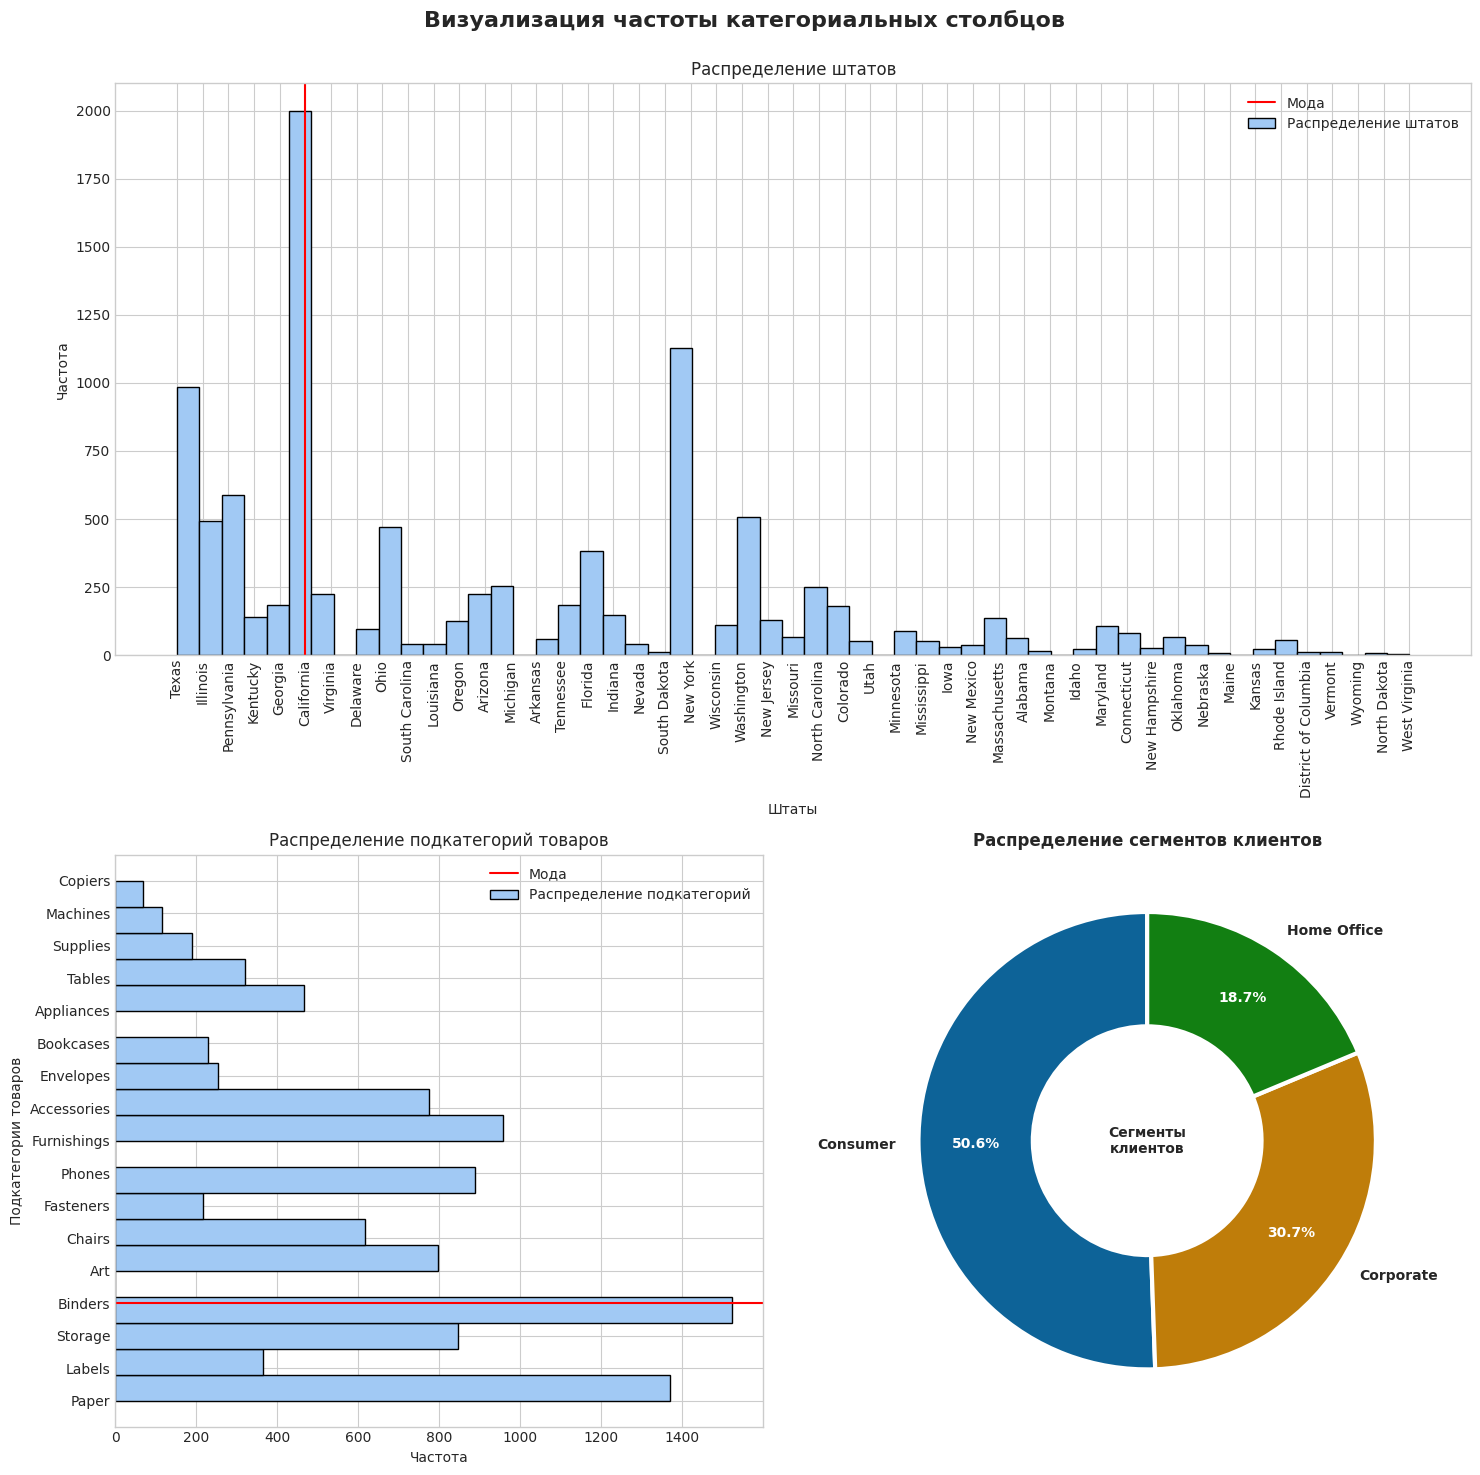

In [75]:
# Визуализация частоты категориальных столбцов
fig = plt.figure(figsize=(15, 15))
fig.suptitle('Визуализация частоты категориальных столбцов', fontsize=16, fontweight='bold')

gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Распределение штатов
ax1.hist(x=df.state, bins=55, color='#a1c9f4', edgecolor='black')
ax1.tick_params(axis='x', rotation=90)
ax1.set_title('Распределение штатов', fontsize=12)
ax1.set_xlabel('Штаты')
ax1.set_ylabel('Частота')
ax1.axvline(stats.mode(df.state), color='red')
ax1.legend(['Мода', 'Распределение штатов'])

# Распределение подкатегорий товаров
ax2.hist(df.sub_category, bins=20, color='#a1c9f4', edgecolor='black', orientation='horizontal')
ax2.set_title('Распределение подкатегорий товаров', fontsize=12)
ax2.set_xlabel('Частота')
ax2.set_ylabel('Подкатегории товаров')
ax2.axhline(stats.mode(df.sub_category), color='red')
ax2.legend(['Мода', 'Распределение подкатегорий'])

# Распределение подкатегорий товаров
df_segments = df.set_index('segment')['sales'].reset_index().groupby('segment').sales.sum()
wedges, texts, autotexts = ax3.pie(df_segments, labels=df_segments.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=["#0d6398", "#BF7D0A", "#127F12"],
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3),
        pctdistance=0.75, labeldistance=1.1
        )

for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.text(0, 0, 'Сегменты\nклиентов', fontweight='bold', ha='center', va='center')
ax3.set_title('Распределение сегментов клиентов', fontweight='bold', fontsize=12)

# Вывод
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Для категориальных столбцов акутально вычислить моду (самое часто встречающееся значение): Самое большое количество заказов сделали <b>рядовые покупатели</b>, самые прибыльные магазины в штате <b>Калифорния</b>, самая продаваемая подкатегория товаров это <b>папка-скоросшиватель</b> (офисные принадлежности).<br>

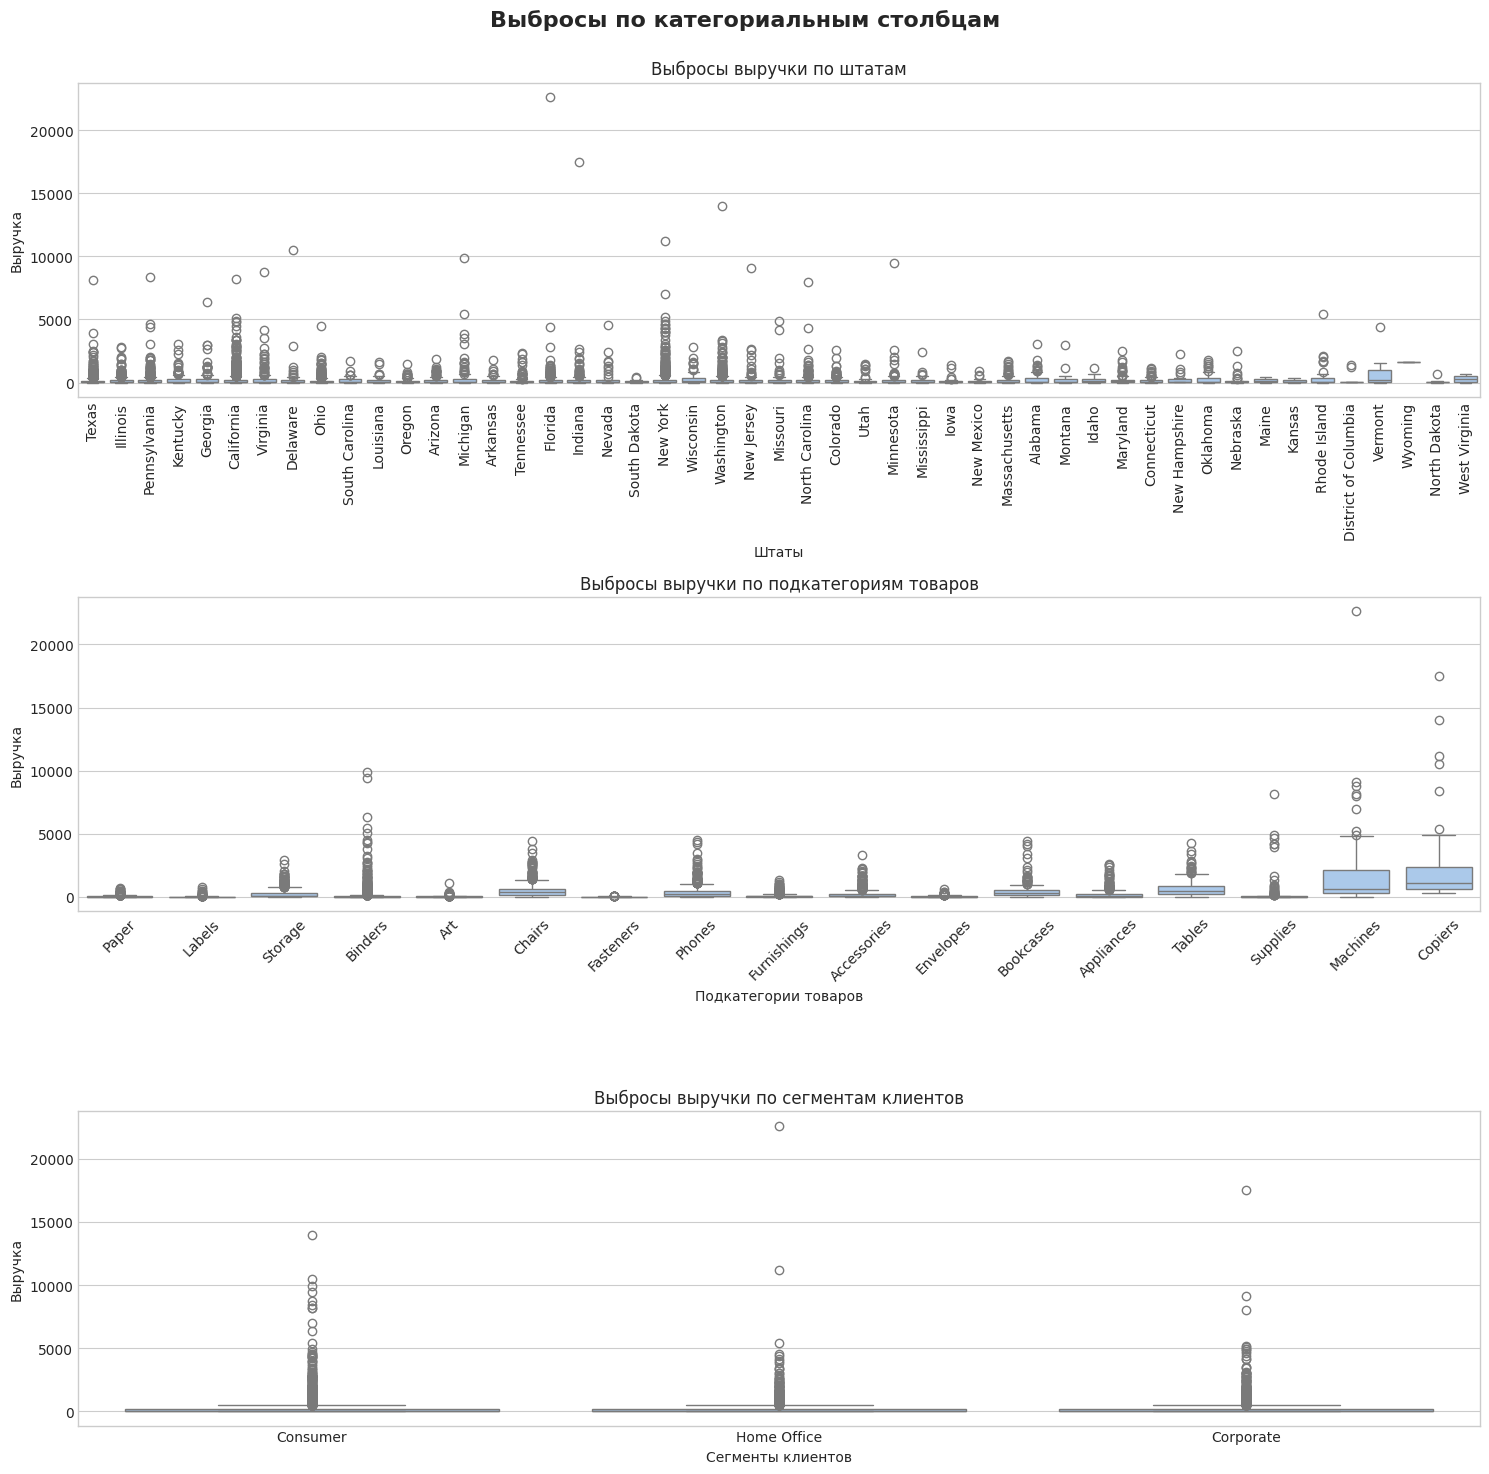

In [ ]:
# Выбросы по категориальным столбцам
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
fig.suptitle('Выбросы по категориальным столбцам', fontsize=16, fontweight='bold')

sns.boxplot(df, x=df.state, y=df.sales, color='#a1c9f4', ax=axes[0])
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xlabel('Штаты')
axes[0].set_ylabel('Выручка')
axes[0].set_title('Выбросы выручки по штатам', fontsize=12)

sns.boxplot(df, x=df.sub_category, y=df.sales, color='#a1c9f4', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Подкатегории товаров')
axes[1].set_ylabel('Выручка')
axes[1].set_title('Выбросы выручки по подкатегориям товаров', fontsize=12)

sns.boxplot(df, x=df.segment, y=df.sales, color='#a1c9f4', ax=axes[2])
axes[2].set_xlabel('Сегменты клиентов')
axes[2].set_ylabel('Выручка')
axes[2].set_title('Выбросы выручки по сегментам клиентов', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

По данным графикам четко видно большое количество выбросов выручки. Есть единичные крупные продажи по штатам, по подкатегориям товаров и по сегментам покупателей.<br> - В штате Флорида была очень крупная покупка более $20 000 клиентом, также в графике по подкатегориям товаров видно, что самая большая выручка идет с продажи автомобилей (также более $20 000). Если посмотреть в график выручки по сегментов покупателей, можно заметить покупку на более $20 000 у сегмента "Домашнего офиса". Вероятно что данные наблюдения связаны между собой.<br>

<h3><strong> 5. ВРЕМЕННОЙ АНАЛИЗ</strong></h3>
В этапе будет показана динамика продаж в течение всего времени, охваченной в таблице продаж, а также будет выявлена сезонность продаж.

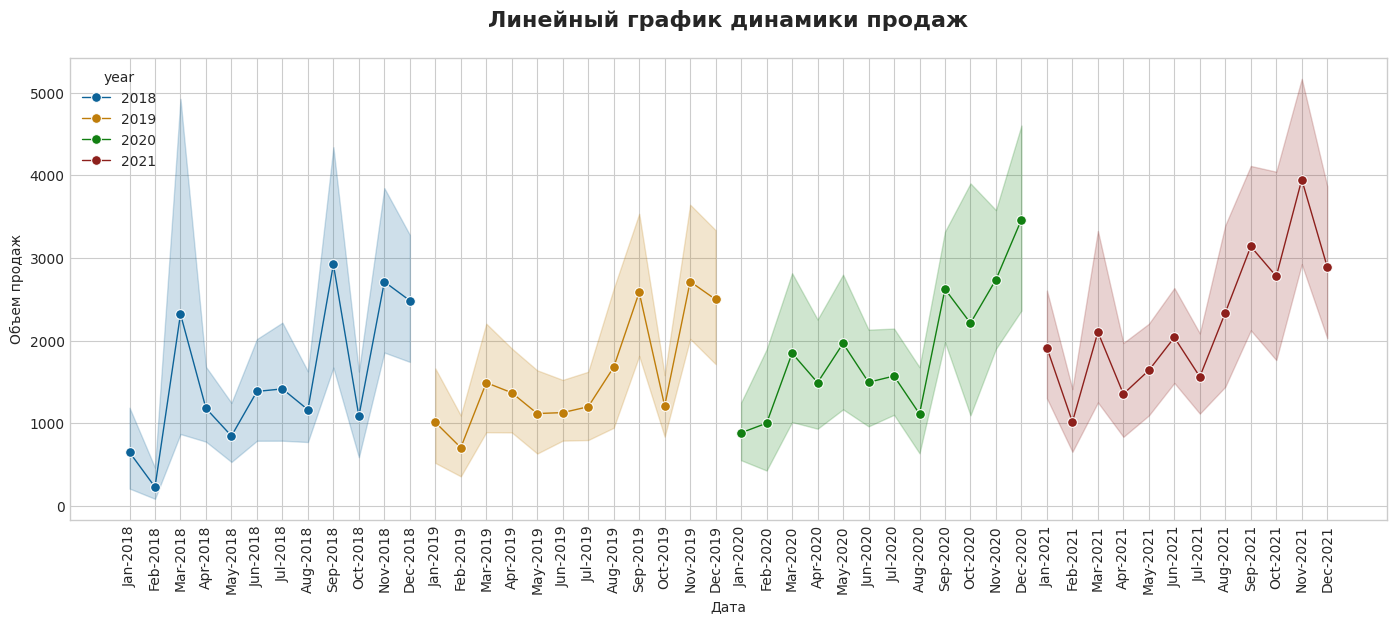

In [ ]:
# Для временного анализа отделим столбцы order_date и sales в новый dataframe
df_date = df[['order_date', 'sales']].copy()
df_date['day'] = df_date.order_date.dt.day
df_date['month'] = df_date.order_date.dt.month
df_date['month_name'] = df_date.order_date.dt.strftime('%B').str[:3]
df_date['quarter'] = 'Q' + df_date.order_date.dt.quarter.astype(str)
df_date['year'] = df_date.order_date.dt.year

# Группировка для дальнейшей отрисовки графика
df_grouped = df_date.groupby(['day', 'month', 'month_name', 'year']).sales.sum().reset_index()
df_grouped = df_grouped.sort_values(['year', 'month'])
df_grouped['month_year'] = df_grouped.month_name + '-' + df_grouped.year.astype(str)

# Линейный график динамики продаж 
plt.figure(figsize=(17, 6))
plt.title('Линейный график динамики продаж', fontsize=16, fontweight='bold', y=1.05)
sns.lineplot(data=df_grouped, x='month_year', y='sales', 
             hue='year', palette=["#0d6398", "#BF7D0A", "#127F12", "#8D201C"],
             marker='o', markersize=7, linewidth=1)
plt.xticks(rotation=90)
plt.xlabel('Дата')
plt.ylabel('Объем продаж')
plt.show()

В данном линейном графике показан рост продаж от года в год. Четко замечена закономерность движения линии внутри годов, линии почти одинаковые, это показывает, что сезонность от года в год сохраняется, для более четкого определения предоставлен график сезонности без учета годов.

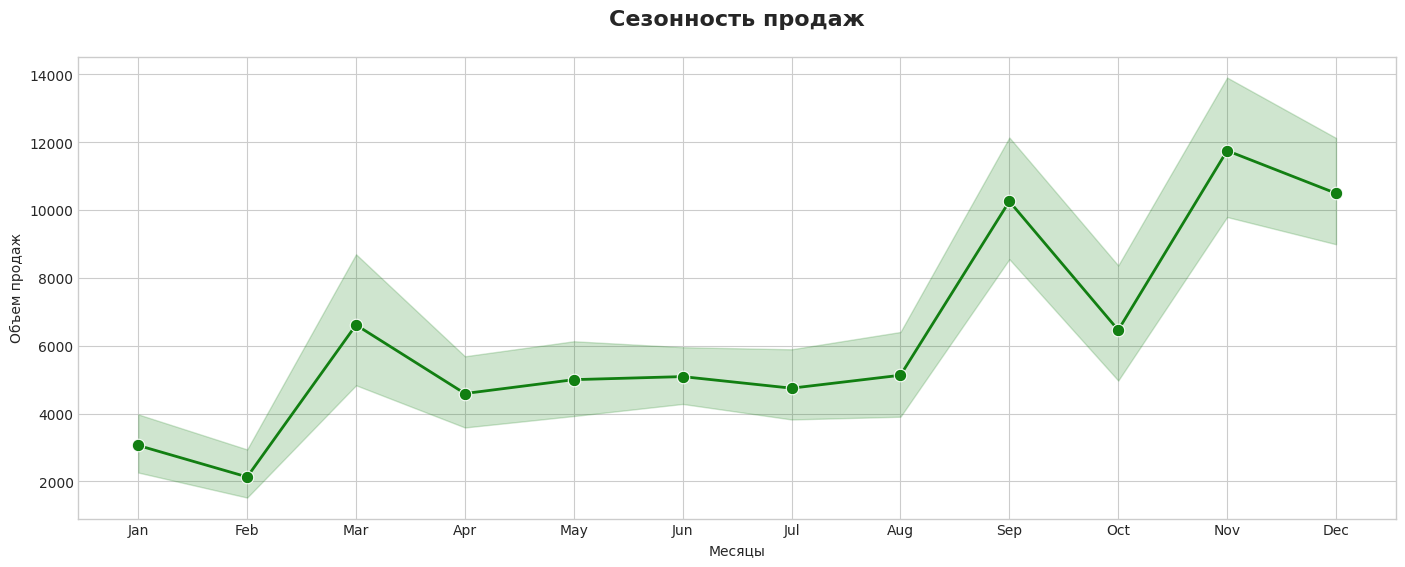

In [ ]:
# Линейный график сезонности
df_season = df_date.groupby(['quarter', 'month', 'month_name', 'day']).sales.sum().reset_index()

plt.figure(figsize=(17, 6))
plt.title('Сезонность продаж', fontsize=16, fontweight='bold', y=1.05)
sns.lineplot(data=df_season, x='month_name', y='sales',
            color='#127F12', # hue='quarter', 
            marker='o', markersize=9, linewidth=2)
plt.xlabel('Месяцы')
plt.ylabel('Объем продаж')
plt.show()

Начало года определено низкими продажами, в феврале даже глобальный минимум; в марте начинается рост (может быть связан с весенними распродажами и скидками), что и замечается осенью после стабильного лета. Также рост продаж может быть связано с праздничными днями.